SCKIT-LEARN


In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [11]:
heart_disease = pd.read_csv("heart-disease.csv")



In [12]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [13]:
## SPILITING INTO X AND Y
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

In [2]:
# Random Forest Classifier (for classification problems)
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Define your feature matrix X and target vector y
# For example:
X = np.random.rand(100, 4)  # 100 samples, 4 features
y = np.random.randint(0, 2, 100)  # Binary classification target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the classifier
clf = RandomForestClassifier(n_estimators=100)  # You may need to specify parameters based on your needs

# Now fit the classifier to your training data
clf.fit(X_train, y_train)

RandomForestClassifier()

In [3]:
# Assuming X_test contains your test features
y_preds = clf.predict(X_test)  # Use X_test instead of y_test

# If you really need to reshape y_test for some reason, you can do:
# y_preds = clf.predict(y_test.reshape(-1, 1))  # Reshape to 2D array with one feature

## EVALUATING A MODEL
1)ESTIMATING BUILT IN SCORE () METHOD
2)THE SCORING PARAMETER
3)PROBLEM SPEECIFIC METRIC FUNCTIONS

In [4]:
clf.score(X_train,y_train)

1.0

In [5]:
clf.score(X_test,y_test)

0.4

## SCORING PARAMETER

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Define your feature matrix X and target vector y
# For example:
X = np.random.rand(100, 4)  # 100 samples, 4 features
y = np.random.randint(0, 2, 100)  # Binary classification target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the classifier
clf = RandomForestClassifier(n_estimators=100)  # You may need to specify parameters based on your needs

# Now fit the classifier to your training data
clf.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
clf.score(X_test,y_test)

0.4

In [8]:
cross_val_score(clf,X,y,cv=5)

array([0.35, 0.5 , 0.65, 0.4 , 0.5 ])

## CLASSIFICATION MODEL EVALUATION METRICS

1)Accuracy
2)Area under ROC curve
3)Confusion Matrix
4)Classification Report

In [11]:
##### 1)ACCURACY

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the classifier
clf = RandomForestClassifier(n_estimators=100)  # You may need to specify parameters based on your needs

# Now fit the classifier to your training data
clf.fit(X_train, y_train)

cross_val_score(clf,X,y,cv=5)


array([0.5 , 0.5 , 0.55, 0.3 , 0.45])

In [14]:
scores = cross_val_score(clf, X, y, cv=5)  # cv=5 for 5-fold cross-validation

# Calculate the mean of the scores
mean_score = np.mean(scores)
print(mean_score)

0.51


In [15]:
mean_accuracy = np.mean(scores) * 100
# Print the accuracy as a percentage with 2 decimal places
print(f"Accuracy: {mean_accuracy:.2f}%")

Accuracy: 51.00%


## area under the reciever operating characterstics curve (AUC/ROC)
> AREA UNDER ROC
> AUC

Area under the receiver operating characteristic curve (AUC/ROC)

Area under curve (AUC)
ROC curve
ROC curves are a comparison of a model's true postive rate (tpr) versus a models false positive rate (fpr).

True positive = model predicts 1 when truth is 1
False positive = model predicts 1 when truth is 0
True negative = model predicts 0 when truth is 0
False negative = model predicts 0 when truth is 1

In [17]:
from sklearn.metrics import roc_curve

# Fit the classifier
clf.fit(X_train, y_train)

# Make predictions with probabilities
y_probs = clf.predict_proba(X_test)

y_probs[:10], len(y_probs)

(array([[0.34, 0.66],
        [0.68, 0.32],
        [0.66, 0.34],
        [0.43, 0.57],
        [0.47, 0.53],
        [0.3 , 0.7 ],
        [0.59, 0.41],
        [0.62, 0.38],
        [0.36, 0.64],
        [0.5 , 0.5 ]]),
 20)

In [18]:
y_probs_positive = y_probs[:, 1]
y_probs_positive[:10]

array([0.66, 0.32, 0.34, 0.57, 0.53, 0.7 , 0.41, 0.38, 0.64, 0.5 ])

In [19]:
# Caculate fpr, tpr and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

# Check the false positive rates
fpr

array([0.        , 0.07692308, 0.15384615, 0.30769231, 0.30769231,
       0.61538462, 0.69230769, 0.76923077, 0.76923077, 0.76923077,
       1.        , 1.        ])

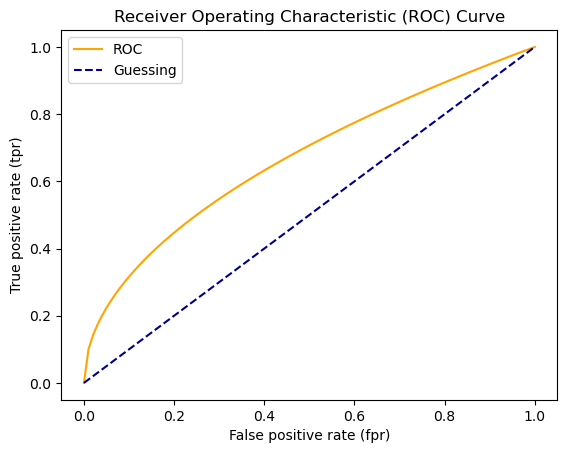

In [3]:
import matplotlib.pyplot as plt
import numpy as np  # Added to create sample data

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false positive rate (fpr)
    and true positive rate (tpr) of a model.
    """
    # Plot roc curve
    plt.plot(fpr, tpr, color="orange", label="ROC")
    # Plot line with no predictive power (baseline)
    plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--", label="Guessing")
    
    # Customize the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

# Create sample data for fpr and tpr before calling the function
# In a real scenario, these would come from your model evaluation
fpr = np.linspace(0, 1, 100)  # Sample false positive rates from 0 to 1
tpr = np.sqrt(fpr)  # Sample true positive rates (just an example curve)

# Now call the function with the defined variables
plot_roc_curve(fpr, tpr)

In [4]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(X_test)

confusion_matrix(y_test, y_preds)

NameError: name 'clf' is not defined

## regression model evaluation metrics




In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [22]:
import os
os.getcwd()


'C:\\Users\\yatharth'

In [23]:
df = pd.read_csv("C:/Users/yatharth/Downloads/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [25]:
housing_df = pd.read_csv("C:/Users/yatharth/Downloads/Housing.csv")


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

housing_df = pd.read_csv("C:/Users/yatharth/Downloads/Housing.csv")

# Convert categorical columns to numeric
housing_df_encoded = pd.get_dummies(housing_df, drop_first=True)

# Features and target
X = housing_df_encoded.drop("price", axis=1)
y = housing_df_encoded["price"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# Score
model.score(X_test, y_test)


0.611918531405699

In [31]:
y_test.mean()


np.float64(5007536.697247706)

In [33]:
from sklearn.metrics import r2_score

# Fill an array with y_test mean
y_test_mean = np.full(len(y_test), y_test.mean())

In [34]:
y_test_mean[:10]

array([5007536.69724771, 5007536.69724771, 5007536.69724771,
       5007536.69724771, 5007536.69724771, 5007536.69724771,
       5007536.69724771, 5007536.69724771, 5007536.69724771,
       5007536.69724771])

In [35]:
r2_score(y_true=y_test,
         y_pred=y_test_mean)

0.0

In [36]:
r2_score(y_true=y_test,
         y_pred=y_test)

1.0